In [1]:
import numpy as np
from PIL import Image
import gurobipy as gp
from gurobipy import GRB
from IPython.display import display
from collections import defaultdict

In [2]:
# Setup and resizing

numberOfTilesInHeight = 15
numberOfLabyrinthsToFind = 2
sizeOfLineInLaby = 15
imageFile = "lincoln.png"

# Load image as grayscale
img = Image.open(imageFile).convert("L")
targetImage = np.array(img)

#Find the dimensions of the image
heightTarget, widthTarget = targetImage.shape

numberOfTilesInWidth = int(np.floor(widthTarget / heightTarget * (numberOfTilesInHeight + 1)))

#New sizes of image
heightTarget = int(np.floor(heightTarget / numberOfTilesInHeight) * numberOfTilesInHeight)
widthTarget  = int(np.floor(widthTarget / numberOfTilesInWidth) * numberOfTilesInWidth)

#resize the image

targetImage = Image.fromarray(targetImage).resize((widthTarget, heightTarget))

#print(targetImage.size)
#display(targetImage)

#convert back to np array
targetImage = np.array(targetImage)

pixelsInHeight = int(np.floor(heightTarget/numberOfTilesInHeight))
pixelsInWidth  = int(np.floor(widthTarget/numberOfTilesInWidth))

print(pixelsInHeight, pixelsInWidth)

53 50


In [3]:
#Find pixel averages over subblocks

pixelAverage = np.zeros((numberOfTilesInHeight, numberOfTilesInWidth))

pixelRow = 0
for i in range(numberOfTilesInHeight):
    pixelCol = 0
    for j in range(numberOfTilesInWidth):
        block = targetImage[
            pixelRow:pixelRow + pixelsInHeight,
            pixelCol:pixelCol + pixelsInWidth
        ]
        pixelAverage[i, j] = block.mean()
        pixelCol += pixelsInWidth
    pixelRow += pixelsInHeight

In [4]:
#Create indexing of decision variables
# x_i,j,k is whether piece k is placed in block (i,j) where

numberOfTotalTiles = 7
numberOfDecisionVariables = 0
gridIndexing = np.zeros(
    (numberOfTilesInHeight,numberOfTilesInWidth,numberOfTotalTiles), dtype=int)

indexToGrid = []

for i in range(numberOfTilesInHeight):
    for j in range(numberOfTilesInWidth):
        for k in range(numberOfTotalTiles):
            numberOfDecisionVariables += 1
            gridIndexing[i,j,k] = numberOfDecisionVariables
            indexToGrid.append([i, j, k])

indexToGrid = np.array(indexToGrid)

In [5]:
# gurobi setup
m = gp.Model("labyrinth")
x = m.addVars(numberOfTilesInHeight, numberOfTilesInWidth, numberOfTotalTiles, vtype=GRB.BINARY, name="x")

#create constraints - one row per constraint

for i in range(numberOfTilesInHeight):
    for j in range(numberOfTilesInWidth):
        m.addConstr(
            gp.quicksum(x[i, j, k] for k in range(numberOfTotalTiles)) == 1,
            name=f"one_tile_{i}_{j}"
        )

# Constraint - boundaries

#horizontal
for i in range(numberOfTilesInHeight):
    for j in range(numberOfTilesInWidth - 1):
        # first equation: 1,3,5 on (i,j)  ==  2,4,5 on (i,j+1)
        left1 = gp.quicksum(x[i, j, k] for k in [0, 2, 4])   # 1,3,5 → 0,2,4 zero-based
        right1 = gp.quicksum(x[i, j+1, k] for k in [1, 3, 4])
        m.addConstr(left1 - right1 == 0, name=f"horiz1_{i}_{j}")

        # second equation: 2,4,6,7 on (i,j)  ==  1,3,6,7 on (i,j+1)
        left2 = gp.quicksum(x[i, j, k] for k in [1, 3, 5, 6])   # 2,4,6,7 → 1,3,5,6
        right2 = gp.quicksum(x[i, j+1, k] for k in [0, 2, 5, 6])
        m.addConstr(left2 - right2 == 0, name=f"horiz2_{i}_{j}")

#vertical

for i in range(numberOfTilesInHeight - 1):
    for j in range(numberOfTilesInWidth):
        # first equation: 1,2,6 on (i,j) == 3,4,6 on (i+1,j)
        left1 = gp.quicksum(x[i, j, k] for k in [0, 1, 5])   # 1,2,6 → 0,1,5
        right1 = gp.quicksum(x[i+1, j, k] for k in [2, 3, 5])
        m.addConstr(left1 - right1 == 0, name=f"vert1_{i}_{j}")

        # second equation: 3,4,5,7 on (i,j) == 1,2,5,7 on (i+1,j)
        left2 = gp.quicksum(x[i, j, k] for k in [2, 3, 4, 6])   # 3,4,5,7 → 2,3,4,6
        right2 = gp.quicksum(x[i+1, j, k] for k in [0, 1, 4, 6])
        m.addConstr(left2 - right2 == 0, name=f"vert2_{i}_{j}")


Set parameter TokenServer to value "gurobilicense.davidson.edu"


In [6]:
# Set decision variables to zero for those that cannot appear in regions

# upper-left corner (i=0, j=0): 
m.addConstr(x[0, 0, 0] + x[0, 0, 6] == 1, name="upper_left_corner")

# upper-right corner (i=0, j=width-1): 
m.addConstr(x[0, numberOfTilesInWidth - 1, 1] + 
            x[0, numberOfTilesInWidth - 1, 6] == 1,
            name="upper_right_corner")

# lower-right corner (i=height-1, j=width-1):
m.addConstr(x[numberOfTilesInHeight - 1, numberOfTilesInWidth - 1, 3] +
            x[numberOfTilesInHeight - 1, numberOfTilesInWidth - 1, 6] == 1,
            name="lower_right_corner")

# lower-left corner (i=height-1, j=0): 
m.addConstr(x[numberOfTilesInHeight - 1, 0, 2] +
            x[numberOfTilesInHeight - 1, 0, 6] == 1,
            name="lower_left_corner")

# top row (i = 0): k = 3,4,6 → 2,3,5
for j in range(numberOfTilesInWidth):
    for k in [2, 3, 5]:
        m.addConstr(x[0, j, k] == 0, name=f"top_{j}_{k}")


# right column (j = width-1): k = 1,3,5 → 0,2,4
for i in range(numberOfTilesInHeight):
    for k in [0, 2, 4]:
        m.addConstr(x[i, numberOfTilesInWidth - 1, k] == 0,
                    name=f"right_{i}_{k}")


# bottom row (i = height-1): k = 1,2,6 → 0,1,5
for j in range(numberOfTilesInWidth):
    for k in [0, 1, 5]:
        m.addConstr(x[numberOfTilesInHeight - 1, j, k] == 0,
                    name=f"bottom_{j}_{k}")


# left column (j = 0): k = 2,4,5 → 1,3,4
for i in range(numberOfTilesInHeight):
    for k in [1, 3, 4]:
        m.addConstr(x[i, 0, k] == 0, name=f"left_{i}_{k}")



m.update()

In [7]:
# create gurobi objective function
obj = gp.quicksum(
    (pixelAverage[i, j]**2) * x[i, j, k]
    for i in range(numberOfTilesInHeight)
    for j in range(numberOfTilesInWidth)
    for k in range(numberOfTotalTiles - 1)
) + gp.quicksum(
    ((255 - pixelAverage[i, j])**2) * x[i, j, numberOfTotalTiles - 1]
    for i in range(numberOfTilesInHeight)
    for j in range(numberOfTilesInWidth)
)

m.setObjective(obj, GRB.MINIMIZE)

In [8]:
m.setParam('OutputFlag', 0)

# SUBTOUR detection, loop and solving 

for laby in range(numberOfLabyrinthsToFind):

    foundLabyrinth = False

    while not foundLabyrinth:
        m.optimize()

        if m.status != GRB.OPTIMAL:
            print("Model status:", m.status)
            break   # or handle it differently
        
        #What tiles are in the current tour?
        sol = m.getAttr('x', x)

        active_tiles = [(i, j, k) for i, j, k in x.keys() if sol[i, j, k] > 1e-6]

        blank_tiles = [(i,j,k) for (i,j,k) in active_tiles if k == 6]
        non_blank_tiles = [t for t in active_tiles if t[2] != 6]

        #Establish where connections are for sub-tour detection
        connect = {
            0: [(1,0), (0,1)],     # tile 1 → D,R
            1: [(1,0), (0,-1)],    # tile 2 → D,L
            2: [(-1,0), (0,1)],    # tile 3 → U,R
            3: [(-1,0), (0,-1)],   # tile 4 → U,L
            4: [(0,-1), (0,1)],    # tile 5 → L,R
            5: [(-1,0), (1,0)]     # tile 6 → U,D
        }

        #Build adjacency graph
        adj = defaultdict(list)
        
        for (i, j, k) in non_blank_tiles:
            for di, dj in connect[k]:
                ni, nj = i + di, j + dj
                if (ni, nj) in [(x,y) for (x,y,_) in non_blank_tiles]:
                    adj[(i,j)].append((ni,nj))

        # Find connected components (loops)
       
        visited = set()
        loops = []
        
        for node in adj:
            if node not in visited:
                stack = [node]
                component = []
        
                while stack:
                    cur = stack.pop()
                    if cur in visited:
                        continue
                    visited.add(cur)
                    component.append(cur)
        
                    for neighbor in adj[cur]:
                        if neighbor not in visited:
                            stack.append(neighbor)
        
                loops.append(component)


        #Check if valid solution
        total_tiles = numberOfTilesInHeight * numberOfTilesInWidth
        non_blank_count = len(non_blank_tiles)
        
        if len(loops) == 1 and len(loops[0]) == non_blank_count:
            foundLabyrinth = True
            break

        #Add subtour elimination constraint
        for loop in loops:
            if len(loop) < non_blank_count:
                loop_set = {(i, j): k for (i, j, k) in non_blank_tiles if (i, j) in set(loop)}
                m.addConstr(
                    gp.quicksum(
                        x[i, j, k]
                        for (i, j), k in loop_set.items()
                    ) <= len(loop) - 1
                )

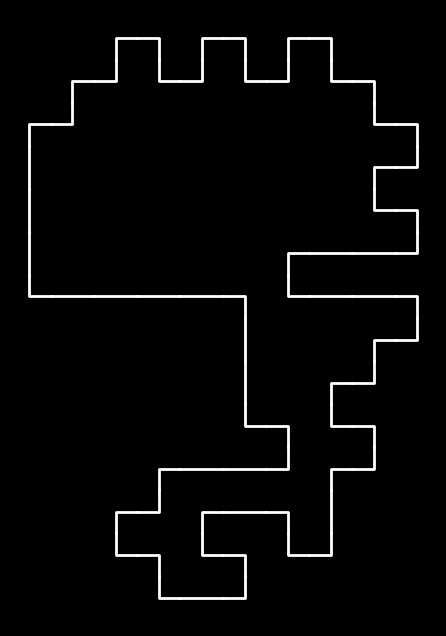

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8), facecolor='black')

for (i, j, k) in active_tiles:
    
    if k == 0:  # case 1
        xPoints = [j+1, (2*j+1)/2, (2*j+1)/2]
        yPoints = [-(2*i+1)/2, -(2*i+1)/2, -(i+1)]

    elif k == 1:  # case 2
        xPoints = [j, (2*j+1)/2, (2*j+1)/2]
        yPoints = [-(2*i+1)/2, -(2*i+1)/2, -(i+1)]

    elif k == 2:  # case 3
        xPoints = [(2*j+1)/2, (2*j+1)/2, j+1]
        yPoints = [-i, -(2*i+1)/2, -(2*i+1)/2]

    elif k == 3:  # case 4
        xPoints = [(2*j+1)/2, (2*j+1)/2, j]
        yPoints = [-i, -(2*i+1)/2, -(2*i+1)/2]

    elif k == 4:  # case 5
        xPoints = [j, j+1]
        yPoints = [-(2*i+1)/2, -(2*i+1)/2]

    elif k == 5:  # case 6
        xPoints = [(2*j+1)/2, (2*j+1)/2]
        yPoints = [-i, -(i+1)]

    elif k == 6:  # case 7 (blank)
        continue

    plt.plot(xPoints, yPoints, 'w-', linewidth=2)

plt.axis('off')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()
